# Review Analysis and Persona Derivation
- Source: `03.CX_Group4/data/keyword_reviews.xlsx`
- Goal: Analyze reviews, extract key themes, cluster user intents, and define data-driven personas with actionable strategies.

In [1]:
# Setup: imports and environment check
import sys, os, platform
print({
    'python': sys.version,
    'executable': sys.executable,
    'platform': platform.platform()
})

# Lightweight import set; we'll install missing libs inline if needed via %pip
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# NLP
try:
    import scikit_learn  # noqa: F401
except Exception:
    pass
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Utils
from collections import Counter
import re

# Notebook niceties
try:
    from tqdm.auto import tqdm
except ModuleNotFoundError:
    pass

# Helper: safe pip install into active kernel (use if import fails)
def pip_install(pkgs):
    import subprocess, sys
    cmd = [sys.executable, '-m', 'pip', 'install', *pkgs]
    subprocess.check_call(cmd)
    


{'python': '3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]', 'executable': 'c:\\Python312\\python.exe', 'platform': 'Windows-11-10.0.26100-SP0'}


In [2]:
# Load data
DATA_PATH = r'c:\\Users\\lgdx\\LG_DX_School\\03.CX_Group4\\data\\keyword_reviews.xlsx'
assert os.path.exists(DATA_PATH), f'Missing file: {DATA_PATH}'

df = pd.read_excel(DATA_PATH)
print('Shape:', df.shape)
print('Columns:', list(df.columns))

df.sample(3, random_state=42)

Shape: (139, 2)
Columns: ['keyword', 'review']


,keyword,review
135,않다,내돈내산 그램 인치 블랙 구매 후기 이런 물건은 내돈내산 아니고 협찬받아 포스팅 거...
66,개다,올해 월쯤에 그램 인치 구입해서 사용중입니다 근데 생각보다 인치가 크고 밖에 가지고...
31,사용,구매 돈 내산 후기입니다 블로그 개인 업무용으로 월에 노트북을 하나구매했었는데 무겁...


In [3]:
# Identify the review text column heuristically
text_col_candidates = [
    'review', 'text', 'content', '리뷰', '내용', '본문', 'comment', 'comments', 'review_text'
]
text_col = None
for c in df.columns:
    if c.lower() in text_col_candidates:
        text_col = c
        break
if text_col is None:
    # fallback: pick the longest average length text-like column
    text_like = [c for c in df.columns if df[c].dtype == 'object']
    if not text_like:
        raise ValueError('No text-like column found')
    text_col = max(text_like, key=lambda c: df[c].astype(str).str.len().mean())

print('Using text column:', text_col)

# Basic cleaning/tokenization
basic_stopwords = set([
    '그리고','하지만','그러나','또한','및','에서','으로','에게','합니다','했다','하는','하는데','있다','없는','같은','때문','정도','이런','저런','그런','것','수','등','더','좀','너무','매우','진짜','좀','최고','최악','좋아요','별로','그냥','정말','대한','되는','된다'
])

eng_stop = set(['the','and','is','to','of','in','for','on','with','this','that','it','as','are','was','were','be','by','or','an','at','from'])

pat = re.compile(r"[\W_]+", re.UNICODE)

def tokenize(s: str):
    if pd.isna(s):
        return []
    s = str(s).lower()
    s = pat.sub(' ', s)
    toks = [t for t in s.split() if len(t) > 1]
    toks = [t for t in toks if t not in basic_stopwords and t not in eng_stop]
    return toks

# Build a cleaned text column
clean_tokens = df[text_col].apply(tokenize)
df['clean_text'] = clean_tokens.apply(lambda toks: ' '.join(toks))
print('Empty clean rows:', (df['clean_text'].str.len() == 0).sum())
df[['clean_text']].head()

Using text column: review
Empty clean rows: 0


,clean_text
0,예기치 않은 사고로 년도에 구매한 그램이 망가져서 그램 프로 구매하게 되었어요 내돈...
1,구매 내산 후기입니다 블로그 개인 업무용으로 월에 노트북을 하나구매했었는데 무겁고 ...
2,꽃대지입니다 그램 노트북 내돈내산 실사용후기알려드리려고 해요 직접 사용하면서 장점 ...
3,뉴퍼마켓에서 노트북을 구매해 봤습니다 정확히는 삼성카드몰에 입점해 있는 제품이었습니...
4,중고노트북 인치 인텔 세대 엘지그램 화이트 코어 내돈내산 사용후기 사진 클릭 바로 ...


In [4]:
# Vectorize texts (TF-IDF)
min_df = max(2, int(0.01 * len(df)))  # drop ultra-rare terms
vectorizer = TfidfVectorizer(max_features=5000, min_df=min_df, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])
print('TF-IDF shape:', X.shape)

# Topic discovery via NMF (non-probabilistic LSA-like)

def top_terms(W, H, feature_names, topk=10):
    topics = []
    for k in range(H.shape[0]):
        idx = np.argsort(H[k])[::-1][:topk]
        topics.append([feature_names[i] for i in idx])
    return topics

feature_names = np.array(vectorizer.get_feature_names_out())

best_n_topics, best_coh, best_model = None, -np.inf, None
for n_topics in range(4, 9):
    nmf = NMF(n_components=n_topics, random_state=42, init='nndsvda', max_iter=400)
    W = nmf.fit_transform(X)
    H = nmf.components_
    # Coherence-like proxy: average pairwise cosine within top terms is expensive; use sparsity-adjusted explained variance proxy
    topic_strength = (W.mean(axis=0)).mean()
    recon = -nmf.reconstruction_err_
    score = recon + topic_strength
    if score > best_coh:
        best_coh, best_n_topics, best_model = score, n_topics, nmf

print('Best n_topics:', best_n_topics)
W = best_model.transform(X)
H = best_model.components_

nmf_topics = top_terms(W, H, feature_names, topk=12)
for i, terms in enumerate(nmf_topics):
    print(f'Topic {i}:', ', '.join(terms))

df['topic'] = W.argmax(axis=1)

# KMeans clustering on document vectors
best_k, best_sil, best_km = None, -1.0, None
for k in range(3, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels) if k > 1 else -1
    if sil > best_sil:
        best_sil, best_k, best_km = sil, k, km

print('Best K:', best_k, 'Silhouette:', round(best_sil, 3))
df['cluster'] = best_km.predict(X)

# Cluster top terms
cluster_top = {}
for c in sorted(df['cluster'].unique()):
    idx = np.where(df['cluster'].values == c)[0]
    centroid = X[idx].mean(axis=0)
    arr = np.asarray(centroid).ravel()
    topi = arr.argsort()[::-1][:15]
    cluster_top[c] = [feature_names[t] for t in topi]

cluster_top

TF-IDF shape: (139, 5000)
Best n_topics: 8
Topic 0: 할인, 공식, 금액이, 포인트, 구매, 근데, 온라인, 그램, 노트북을, 구매할, 사진, 토탈
Topic 1: 공홈에서, 한글, 버튼이, 그램, 전자, 구매했어요, 전자 공홈에서, 콘센트, 한글 프로그램, 프로, 전원, 제품
Topic 2: 없습니다, 배터리도, 생각보다 비싼, 만족스럽습니다, 웹서핑, 되게, 포트, 게임, 노트북, 비싼, 생각이, 역시
Topic 3: 사용하고, 사용하고 있는, 꽂는, 해요, 있는, 장점, 노트북, 하나는, 꽃대지의, 꽂을, 상품, 칸이
Topic 4: 코어, 세대, 원별점, 원별점 리뷰, 원할인률, 원할인률 원별점, 중고노트북, 중고노트북 인치, 인치 인텔, 인텔 세대, 화이트 코어, 세대 엘지그램
Topic 5: 이게, 모니터를, 원하는, 그램뷰, 쓰기엔, 커버를, 느낌, 아무래도, 부드러운, 수도, 있었다, 엄청
Topic 6: 정품박스패키지 리퍼모델은, 정품박스패키지, 뉴퍼마켓, 리퍼모델은, 조금, 내돈내산, 많이, 보증도 해주고더, 할인이, 리퍼를, 때가 있었어요, 조금 아쉽그렇게
Topic 7: 무선, 안드로이드, 롯데, 우리는, 아내와, 하이마트에서, 연동이, 무선 마우스, 수원, 휴대폰, 세대 인치, 상당히
Best K: 7 Silhouette: 0.483


{0: ['무선',
  '안드로이드',
  '롯데',
  '수원',
  '아내와',
  '무선 마우스',
  '휴대폰',
  '우리는',
  '연동이',
  '하이마트에서',
  '세대 인치',
  '상당히',
  '오피스',
  '마우스',
  '나는'],
 1: ['할인',
  '공식',
  '포인트',
  '금액이',
  '근데',
  '온라인',
  '구매',
  '이리저리',
  '앞에',
  '토탈',
  '추가 할인을',
  '쿠폰',
  '이곳저곳',
  '할인을',
  '근데 이제'],
 2: ['공홈에서',
  '한글',
  '버튼이',
  '전자',
  '한글 프로그램',
  '콘센트',
  '구매했어요',
  '전자 공홈에서',
  '전원',
  '그램',
  '프로',
  '제품',
  '프로그램',
  '이전',
  '최신'],
 3: ['그램',
  '노트북',
  '인치',
  '있는',
  '노트북을',
  '내돈내산',
  '조금',
  '가성비',
  '사용하고',
  '없습니다',
  '전자',
  '들고',
  '그램 인치',
  '많이',
  '추천'],
 4: ['배터리도',
  '생각보다 비싼',
  '만족스럽습니다',
  '웹서핑',
  '포트',
  '되게',
  '없습니다',
  '게임',
  '비싼',
  '역시',
  '없이',
  '생각이',
  '노트북',
  '생각보다',
  '키보드'],
 5: ['이게',
  '모니터를',
  '그램뷰',
  '원하는',
  '커버를',
  '쓰기엔',
  '느낌',
  '부드러운',
  '아무래도',
  '있었다',
  '수도',
  '모니터',
  '엄청',
  '이건',
  '있어서'],
 6: ['코어',
  '세대',
  '원할인률 원별점',
  '원별점',
  '원별점 리뷰',
  '원할인률',
  '중고노트북',
  '중고노트북 인치',
  '엘지그램 화이트',
  '세대 엘지그램',
  '화이트 코어',
  '인치 인텔',
  '인텔 세대',
  '당신

In [5]:
# Sentiment proxy (very simple): positive/negative lexicon counts
pos_words = set(['좋다','만족','추천','훌륭','편하','예쁘','가성비','빠르','친절','유용','대만족','최고'])
neg_words = set(['불편','불만','최악','느리','비싸','문제','고장','실망','별로','짜증','불량','아쉬'])

def sentiment_score(tokens):
    if not tokens:
        return 0
    p = sum(t in pos_words for t in tokens)
    n = sum(t in neg_words for t in tokens)
    return p - n

if 'Satisfaction' in df.columns:
    df['sentiment'] = df['Satisfaction']
else:
    df['sentiment'] = clean_tokens.apply(sentiment_score)

# Importance proxy: TF-IDF norm per doc (engagement) or length
from numpy.linalg import norm
row_norm = np.asarray(X.power(2).sum(axis=1)).ravel() ** 0.5
length = df['clean_text'].str.split().apply(len).values
importance = 0.7 * (row_norm / (row_norm.max() or 1)) + 0.3 * (length / (length.max() or 1))

df['importance'] = importance

# Segment summary by cluster
grp = df.groupby('cluster').agg(
    n=('clean_text','size'),
    avg_sentiment=('sentiment','mean'),
    avg_importance=('importance','mean')
).reset_index()

# Attach top terms for readability
grp['top_terms'] = grp['cluster'].map(cluster_top)

# Opportunity: high importance but low sentiment
grp['opportunity'] = grp['avg_importance'] - (grp['avg_sentiment'] - df['sentiment'].min()) / (df['sentiment'].max() - df['sentiment'].min() + 1e-9)

grp.sort_values(['opportunity','avg_importance'], ascending=[False, False])

,cluster,n,avg_sentiment,avg_importance,top_terms,opportunity
0,0,9,0.000000,0.829800,"[무선, 안드로이드, 롯데, 수원, 아내와, 무선 마우스, 휴대폰, 우리는, 연동이...",0.445185
1,1,12,0.000000,0.818853,"[할인, 공식, 포인트, 금액이, 근데, 온라인, 구매, 이리저리, 앞에, 토탈, ...",0.434238
2,2,12,0.000000,0.771937,"[공홈에서, 한글, 버튼이, 전자, 한글 프로그램, 콘센트, 구매했어요, 전자 공홈...",0.387322
6,6,10,0.000000,0.758645,"[코어, 세대, 원할인률 원별점, 원별점, 원별점 리뷰, 원할인률, 중고노트북, 중...",0.374029
4,4,11,0.000000,0.751086,"[배터리도, 생각보다 비싼, 만족스럽습니다, 웹서핑, 포트, 되게, 없습니다, 게임...",0.366471
5,5,9,1.000000,0.763858,"[이게, 모니터를, 그램뷰, 원하는, 커버를, 쓰기엔, 느낌, 부드러운, 아무래도,...",0.302319
3,3,76,1.197368,0.761300,"[그램, 노트북, 인치, 있는, 노트북을, 내돈내산, 조금, 가성비, 사용하고, 없...",0.284580


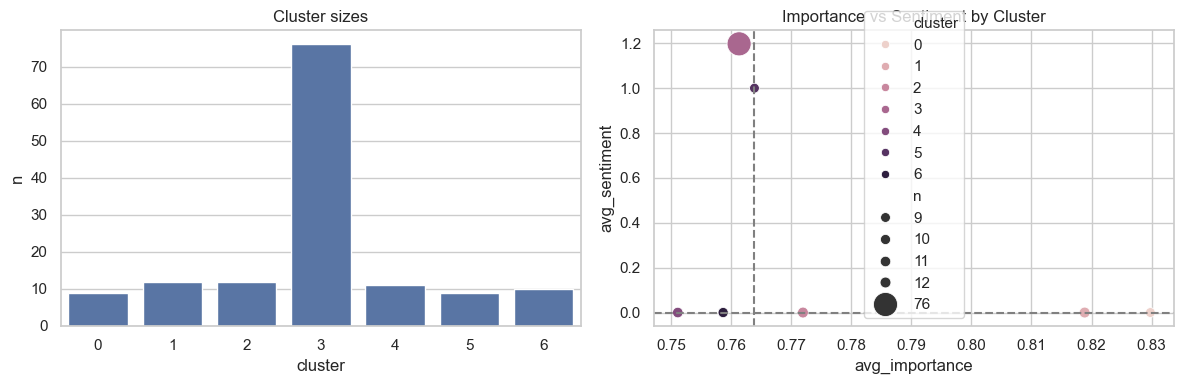

,name,size,traits,needs,pain_points,sentiment,importance,opportunity
0,"Cluster 3 — 그램, 노트북, 인치 중시형",76,"[그램, 노트북, 인치, 있는, 노트북을, 내돈내산, 조금, 가성비]","[그램, 인치, 노트북을, 조금]","[노트북, 있는, 내돈내산, 가성비]",1.197368,0.761300,0.284580
1,"Cluster 1 — 할인, 공식, 포인트 중시형",12,"[할인, 공식, 포인트, 금액이, 근데, 온라인, 구매, 이리저리]","[할인, 포인트, 근데, 구매]","[공식, 금액이, 온라인, 이리저리]",0.000000,0.818853,0.434238
2,"Cluster 2 — 공홈에서, 한글, 버튼이 중시형",12,"[공홈에서, 한글, 버튼이, 전자, 한글 프로그램, 콘센트, 구매했어요, 전자 공홈에서]","[공홈에서, 버튼이, 한글 프로그램, 구매했어요]","[한글, 전자, 콘센트, 전자 공홈에서]",0.000000,0.771937,0.387322
3,"Cluster 4 — 배터리도, 생각보다 비싼, 만족스럽습니다 중시형",11,"[배터리도, 생각보다 비싼, 만족스럽습니다, 웹서핑, 포트, 되게, 없습니다, 게임]","[배터리도, 만족스럽습니다, 포트, 없습니다]","[생각보다 비싼, 웹서핑, 되게, 게임]",0.000000,0.751086,0.366471
4,"Cluster 6 — 코어, 세대, 원할인률 원별점 중시형",10,"[코어, 세대, 원할인률 원별점, 원별점, 원별점 리뷰, 원할인률, 중고노트북, 중...","[코어, 원할인률 원별점, 원별점 리뷰, 중고노트북]","[세대, 원별점, 원할인률, 중고노트북 인치]",0.000000,0.758645,0.374029
5,"Cluster 0 — 무선, 안드로이드, 롯데 중시형",9,"[무선, 안드로이드, 롯데, 수원, 아내와, 무선 마우스, 휴대폰, 우리는]","[무선, 롯데, 아내와, 휴대폰]","[안드로이드, 수원, 무선 마우스, 우리는]",0.000000,0.829800,0.445185
6,"Cluster 5 — 이게, 모니터를, 그램뷰 중시형",9,"[이게, 모니터를, 그램뷰, 원하는, 커버를, 쓰기엔, 느낌, 부드러운]","[이게, 그램뷰, 커버를, 느낌]","[모니터를, 원하는, 쓰기엔, 부드러운]",1.000000,0.763858,0.302319


In [6]:
# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.barplot(data=grp.sort_values('n', ascending=False), x='cluster', y='n', ax=axes[0])
axes[0].set_title('Cluster sizes')
sns.scatterplot(data=grp, x='avg_importance', y='avg_sentiment', size='n', hue='cluster', ax=axes[1], sizes=(50,300))
axes[1].axvline(grp['avg_importance'].median(), ls='--', c='gray')
axes[1].axhline(grp['avg_sentiment'].median(), ls='--', c='gray')
axes[1].set_title('Importance vs Sentiment by Cluster')
plt.tight_layout()
plt.show()

# Persona synthesis (template)
personas = []
for _, row in grp.sort_values('n', ascending=False).iterrows():
    c = int(row['cluster'])
    persona = {
        'name': f"Cluster {c} — {', '.join(row['top_terms'][:3]).title()} 중시형",
        'size': int(row['n']),
        'traits': row['top_terms'][:8],
        'needs': [row['top_terms'][i] for i in range(0, min(8, len(row['top_terms'])), 2)],
        'pain_points': [row['top_terms'][i] for i in range(1, min(8, len(row['top_terms'])), 2)],
        'sentiment': float(row['avg_sentiment']),
        'importance': float(row['avg_importance']),
        'opportunity': float(row['opportunity'])
    }
    personas.append(persona)

pd.DataFrame(personas)

## Strategy recommendations
- Prioritize clusters with high opportunity (high importance, low sentiment)
- Draft targeted actions tied to top terms and persona needs/pains
- Validate with a quick user test or additional sample reviews

Next steps:
- Replace sentiment proxy with a proper Korean sentiment model (e.g., KoNLPy + domain lexicon or KoBERT)
- Tune vectorization (stopwords, bi/trigrams) and try LDA for interpretable topics
- Add representative quotes per cluster to humanize personas